# Word 2 Vec

In [54]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from sklearn.metrics import accuracy_score
import math
import random
import re
import string
from collections import defaultdict
from collections import Counter
import matplotlib.pyplot as plt

In [55]:
splits = {'train': 'train.parquet', 'validation': 'validation.parquet', 'test': 'test.parquet'}
train_df = pd.read_parquet("hf://datasets/cornell-movie-review-data/rotten_tomatoes/" + splits["train"])
test_df = pd.read_parquet("hf://datasets/cornell-movie-review-data/rotten_tomatoes/" + splits["test"])

In [56]:
train_df["text"][:10]

0    the rock is destined to be the 21st century's ...
1    the gorgeously elaborate continuation of " the...
2                       effective but too-tepid biopic
3    if you sometimes like to go to the movies to h...
4    emerges as something rare , an issue movie tha...
5    the film provides some great insight into the ...
6    offers that rare combination of entertainment ...
7    perhaps no picture ever made has more literall...
8    steers turns in a snappy screenplay that curls...
9    take care of my cat offers a refreshingly diff...
Name: text, dtype: object

In [57]:
def tokenize(text):
    return re.findall(r"\b\w+\b", text.lower().translate(str.maketrans('', '', string.punctuation)))

In [58]:
tokens = [tokenize(t) for t in train_df["text"]]

In [59]:
tokens[:10]

[['the',
  'rock',
  'is',
  'destined',
  'to',
  'be',
  'the',
  '21st',
  'centurys',
  'new',
  'conan',
  'and',
  'that',
  'hes',
  'going',
  'to',
  'make',
  'a',
  'splash',
  'even',
  'greater',
  'than',
  'arnold',
  'schwarzenegger',
  'jeanclaud',
  'van',
  'damme',
  'or',
  'steven',
  'segal'],
 ['the',
  'gorgeously',
  'elaborate',
  'continuation',
  'of',
  'the',
  'lord',
  'of',
  'the',
  'rings',
  'trilogy',
  'is',
  'so',
  'huge',
  'that',
  'a',
  'column',
  'of',
  'words',
  'cannot',
  'adequately',
  'describe',
  'cowriterdirector',
  'peter',
  'jacksons',
  'expanded',
  'vision',
  'of',
  'j',
  'r',
  'r',
  'tolkiens',
  'middleearth'],
 ['effective', 'but', 'tootepid', 'biopic'],
 ['if',
  'you',
  'sometimes',
  'like',
  'to',
  'go',
  'to',
  'the',
  'movies',
  'to',
  'have',
  'fun',
  'wasabi',
  'is',
  'a',
  'good',
  'place',
  'to',
  'start'],
 ['emerges',
  'as',
  'something',
  'rare',
  'an',
  'issue',
  'movie',
  '

In [60]:
flat_tokens = [w for sent in tokens for w in sent]
word_counts = Counter(flat_tokens)
vocab = sorted(word_counts.keys())
word_to_id = {w: i for i, w in enumerate(vocab)}
id_to_word = {i: w for w, i in word_to_id.items()}
vocab_size = len(vocab)

In [61]:
print(f"words vocab size = {vocab_size}")

words vocab size = 18221


In [62]:
EMBEDDING_SIZE = 10
CONTEXT_WINDOW_SIZE = 1
NEGATIVES_PER_POSITIVE = 2

In [63]:
def generate_skipgram_pairs(k):
    pairs = set()
    word_context_map = defaultdict(set)
    for sentence in tokens:
        ids = [word_to_id[w] for w in sentence if w in word_to_id]
        for i, center in enumerate(ids):
            # context window
            start = max(0, i - k)
            end = min(len(ids), i + k + 1)
            for j in range(start, end):
                if i == j:
                    continue
                pairs.add((center, ids[j]))
                word_context_map[center].add(ids[j])
    return pairs, word_context_map

In [64]:
pairs, word_context_map = generate_skipgram_pairs(k=CONTEXT_WINDOW_SIZE)
print("Example pairs:", list(pairs)[:10])
print("Total pairs:", len(pairs))

Example pairs: [(11045, 10374), (6255, 5860), (8557, 384), (17858, 14915), (12453, 11037), (12880, 3934), (14926, 747), (6255, 9243), (11762, 16781), (11409, 8557)]
Total pairs: 169315


In [65]:
def sample_negative_words(word_idx, n):
    negatives = set()
    context_words = word_context_map[word_idx]
    while len(negatives) < n:
        neg = random.randint(0, vocab_size - 1)
        if neg not in context_words:
            negatives.add(neg)
    return negatives

In [66]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [67]:
rng = np.random.default_rng(42)
V_in = rng.uniform(-0.5, 0.5, (vocab_size, EMBEDDING_SIZE))  # input embeddings
U_out = rng.uniform(-0.5, 0.5, (vocab_size, EMBEDDING_SIZE)) # output embeddings

In [68]:
#super inefficient
def train_skipgram_step(center_id, context_ids, lr):
    v_c = V_in[center_id]
    grad_v = np.zeros_like(v_c)

    for ctx in context_ids:
        u_o = U_out[ctx]
        s_pos = np.dot(v_c, u_o)
        p_pos = sigmoid(s_pos)
        g_pos = 1 - p_pos
        grad_v += g_pos * u_o
        U_out[ctx] += lr * g_pos * v_c

    # negatives
    n_negatives = math.ceil(len(context_ids) * NEGATIVES_PER_POSITIVE)
    neg_ids = sample_negative_words(center_id, n_negatives)
    for n_id in neg_ids:
        u_n = U_out[n_id]
        s_neg = np.dot(v_c, u_n)
        p_neg = sigmoid(s_neg)
        g_neg = -p_neg
        grad_v += g_neg * u_n
        U_out[n_id] += lr * g_neg * v_c

    V_in[center_id] += lr * grad_v

In [69]:
def train_skipgram_vectorized_step(center_id, context_ids: list, lr):
    v_c = V_in[center_id]

    # positive
    U_pos_vec = U_out[context_ids]
    g_pos_vec = (1 - sigmoid(np.dot(U_pos_vec, v_c)))[:, np.newaxis] / len(context_ids)
    grad_v_pos_vec = np.sum(g_pos_vec * U_pos_vec, axis=0)
    U_out[context_ids] += lr * g_pos_vec * v_c[np.newaxis, :]

    # negative
    n_negatives = math.ceil(len(context_ids) * NEGATIVES_PER_POSITIVE)
    neg_ids = list(sample_negative_words(center_id, n_negatives))

    U_neg_vec = U_out[neg_ids]
    g_neg_vec = (-sigmoid(np.dot(U_neg_vec, v_c)))[:, np.newaxis] / len(neg_ids)
    grad_v_neg_vec = np.sum(g_neg_vec * U_neg_vec, axis=0)
    U_out[neg_ids] += lr * g_neg_vec * v_c[np.newaxis, :]

    V_in[center_id] += lr * (grad_v_pos_vec + grad_v_neg_vec)

In [70]:
V_history = []

In [71]:
def train_skipgram(lr=0.1, epochs=1):
    pair_list = list(pairs)
    for epoch in range(epochs):
        V_history.append(V_in.copy())

        np.random.shuffle(pair_list)
        i = 0
        for center, context in pair_list:
            if i % 10_000 == 0:
                print(f"pair # {i + 1} / {len(pair_list)}")
            train_skipgram_step(center, [context], lr)
            i += 1
        print(f"Epoch {epoch+1}/{epochs} done")

In [72]:
def train_skipgram_vectorized(lr=0.1, epochs=1):
    for epoch in range(epochs):
        V_history.append(V_in.copy())

        for center, context in word_context_map.items():
            train_skipgram_vectorized_step(center, list(context), lr)
        print(f"Epoch {epoch+1}/{epochs} done")

In [ ]:
train_skipgram_vectorized(epochs=100, lr=0.01)

Epoch 1/100 done
Epoch 2/100 done
Epoch 3/100 done
Epoch 4/100 done
Epoch 5/100 done
Epoch 6/100 done
Epoch 7/100 done
Epoch 8/100 done
Epoch 9/100 done
Epoch 10/100 done
Epoch 11/100 done
Epoch 12/100 done
Epoch 13/100 done
Epoch 14/100 done
Epoch 15/100 done
Epoch 16/100 done
Epoch 17/100 done
Epoch 18/100 done
Epoch 19/100 done
Epoch 20/100 done
Epoch 21/100 done
Epoch 22/100 done
Epoch 23/100 done
Epoch 24/100 done
Epoch 25/100 done


# Visualization

In [43]:
from sklearn.decomposition import PCA

In [44]:
sample_words = ["film", "movie", "movies", "rock", "wood", "woman", "man", "like", "enjoyment", "joy", "fun", "great", "common", "weird"]

In [45]:
def show_words_plot(words, embeddings):
    sample_embeddings = []
    labels = []
    for w in words:
        pca = PCA(n_components=2)
        embeddings_2d = pca.fit_transform(embeddings)
        sample_embeddings.append(embeddings_2d[word_to_id[w]])
        labels.append(w)

    sample_embeddings = np.array(sample_embeddings)

    # Plot
    plt.figure(figsize=(8, 6))
    plt.scatter(sample_embeddings[:, 0], sample_embeddings[:, 1], color='red')

    # Add labels
    for i, label in enumerate(labels):
        plt.text(sample_embeddings[i, 0] + 0.01, sample_embeddings[i, 1] + 0.01, label, fontsize=12)

    plt.title("2D Word Embeddings")
    plt.grid(True)
    plt.show()

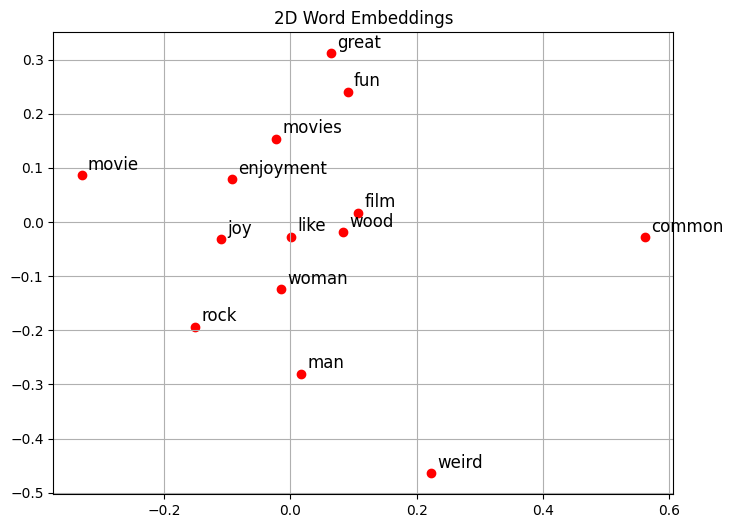

In [46]:
show_words_plot(sample_words, V_history[0])

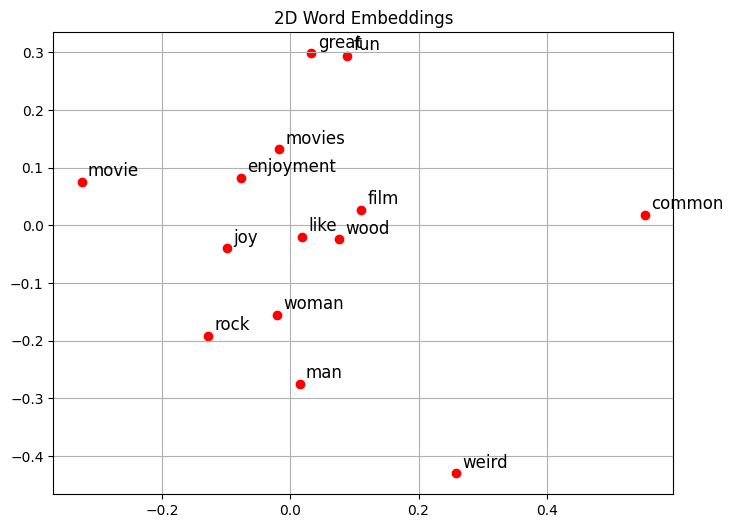

In [47]:
show_words_plot(sample_words, V_history[5])

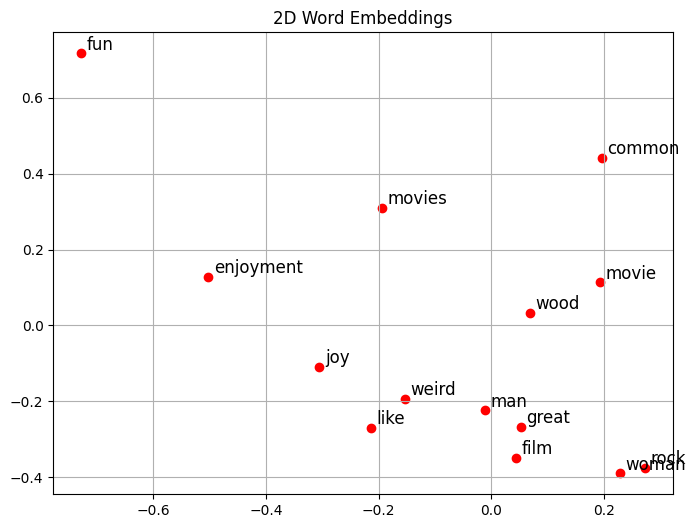

In [48]:
show_words_plot(sample_words, V_history[-1])